# BMM OR MATMUL

In [1]:
import numpy as np
import torch
import torch.utils.benchmark as benchmark
#import jax
#import jax.numpy as jnp
# mute this since it requires py3.8 and py3.10 env, not default py3.11
import tensorflow as tf
import iree.compiler
import iree.runtime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import wraps
from time import perf_counter
from collections import namedtuple

from ragdoll.utils import *
from ragdoll.visualisation import *
from ragdoll.benchmark import *
import ragdoll
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

2024-03-29 14:33:23.301241: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1


In [2]:

ragdoll_results = []
ragdoll_throughput = []
for size in list(range(16, 1300, 16)):
    M = size
    N = size
    K = size
    print("benchmarking {}x{}x{}".format(size, size, size))
    BENCH_CNT=33
    mm_src = f"""module BRKLEFT
      func.func @matmul(%arg0: tensor<{M}x{K}xf32>, %arg1: tensor<{K}x{N}xf32>) -> tensor<{M}x{N}xf32> BRKLEFT
        %cst = arith.constant 0.000000e+00 : f32
        %0 = tensor.empty() : tensor<{M}x{N}xf32>
        %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<{M}x{N}xf32>) -> tensor<{M}x{N}xf32>
        %2 = linalg.matmul ins(%arg0, %arg1 : tensor<{M}x{K}xf32>, tensor<{K}x{N}xf32>) outs(%1 : tensor<{M}x{N}xf32>) -> tensor<{M}x{N}xf32>
        return %2 : tensor<{M}x{N}xf32>
      BRKRIGHT
    BRKRIGHT"""

    mm_src = mm_src.replace("BRKLEFT", "{")
    mm_src = mm_src.replace("BRKRIGHT", "}")
    
    mlir_file_name = "mm_src.mlir"
    with open(mlir_file_name, "w", encoding="utf-8") as mlir_file:
        mlir_file.write(mm_src)
    """
    !iree-compile {mlir_file_name} \
    -o {mlir_file_name}.vmfb \
    --iree-hal-target-backends=cuda \
    --iree-hal-benchmark-dispatch-repeat-count={BENCH_CNT} \
    --iree-hal-cuda-llvm-target-arch=sm_86
    """
    
    !iree-compile {mlir_file_name} \
    -o {mlir_file_name}.vmfb \
    --iree-hal-target-backends=llvm-cpu \
    --iree-llvmcpu-debug-symbols=false \
    --iree-llvmcpu-target-triple=x86_64-pc-linux-elf
    """
    --iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0 \
    --iree-opt-const-eval=1 \
    --iree-opt-const-expr-hoisting=1 \
    --iree-opt-numeric-precision-reduction=1 \
    --iree-llvmcpu-target-cpu-features=host \
    --iree-llvmcpu-enable-ukernels=all \
    --iree-llvmcpu-slp-vectorization=1 \
    --iree-hal-benchmark-dispatch-repeat-count={BENCH_CNT} \
    --iree-llvmcpu-target-triple=x86_64-pc-linux-elf
    """
    #print(tf_bench)
    
    
    ragdoll_bench = ragdoll_op_benchmark(
        mlir_file_name + ".vmfb",
        [(M, K), (K, N)],
        device='cpu',
        warmups=3,
        repetitions=BENCH_CNT, 
        measure_count=1)
    #print(np.mean(ragdoll_bench))
    ragdoll_results.append(np.mean(ragdoll_bench))
    GFLOPS = 2*M*K*N*1000000000
    ragdoll_throughput.append(GFLOPS/np.mean(ragdoll_bench))
ragdoll_data = pd.DataFrame([list(range(16, 1300, 16)), ragdoll_results])
ragdoll_data.to_csv('ragdoll_output_cpu.csv')

benchmarking 16x16x16


/root/AlbertResearches/researches/Ragdoll/ragdoll/benchmark/op_benchmark.py:163: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)


benchmarking 32x32x32
benchmarking 48x48x48
benchmarking 64x64x64
benchmarking 80x80x80
benchmarking 96x96x96
benchmarking 112x112x112
benchmarking 128x128x128
benchmarking 144x144x144
benchmarking 160x160x160
benchmarking 176x176x176
benchmarking 192x192x192
benchmarking 208x208x208
benchmarking 224x224x224
benchmarking 240x240x240
benchmarking 256x256x256
benchmarking 272x272x272
benchmarking 288x288x288
benchmarking 304x304x304
benchmarking 320x320x320
benchmarking 336x336x336
benchmarking 352x352x352
benchmarking 368x368x368
benchmarking 384x384x384
benchmarking 400x400x400
benchmarking 416x416x416
benchmarking 432x432x432
benchmarking 448x448x448
benchmarking 464x464x464
benchmarking 480x480x480
benchmarking 496x496x496
benchmarking 512x512x512
benchmarking 528x528x528
benchmarking 544x544x544
benchmarking 560x560x560
benchmarking 576x576x576
benchmarking 592x592x592
benchmarking 608x608x608
benchmarking 624x624x624
benchmarking 640x640x640
benchmarking 656x656x656
benchmarking 67

In [3]:
torch_results = []
torch_throughput = []
for size in list(range(16, 1300, 16)):
    M = size
    N = size
    K = size
    print("benchmarking {}x{}x{}".format(size, size, size))
    BENCH_CNT=33


    # cpu or gpu
    torch_bench = torch_op_benchmark('matmul', 
                                     [(M, K), (K, N)], 
                                     device='cpu',
                                     warmups=0,
                                     repetitions=BENCH_CNT, 
                                     measure_count=11)
    #print(torch_bench)

    torch_results.append(np.mean(torch_bench))
    GFLOPS = 2*M*K*N*1000000000
    torch_throughput.append(GFLOPS/np.mean(torch_bench))
    #tf_results.append(np.mean(tf_bench))
    #ragdoll_results.append(np.mean(ragdoll_bench))
torch_data = pd.DataFrame([list(range(16, 1300, 16)), torch_results])
torch_data.to_csv('torch_output_cpu.csv')

benchmarking 16x16x16
benchmarking 32x32x32
benchmarking 48x48x48
benchmarking 64x64x64
benchmarking 80x80x80
benchmarking 96x96x96
benchmarking 112x112x112
benchmarking 128x128x128
benchmarking 144x144x144
benchmarking 160x160x160
benchmarking 176x176x176
benchmarking 192x192x192
benchmarking 208x208x208
benchmarking 224x224x224
benchmarking 240x240x240
benchmarking 256x256x256
benchmarking 272x272x272
benchmarking 288x288x288
benchmarking 304x304x304
benchmarking 320x320x320
benchmarking 336x336x336
benchmarking 352x352x352
benchmarking 368x368x368
benchmarking 384x384x384
benchmarking 400x400x400
benchmarking 416x416x416
benchmarking 432x432x432
benchmarking 448x448x448
benchmarking 464x464x464
benchmarking 480x480x480
benchmarking 496x496x496
benchmarking 512x512x512
benchmarking 528x528x528
benchmarking 544x544x544
benchmarking 560x560x560
benchmarking 576x576x576
benchmarking 592x592x592
benchmarking 608x608x608
benchmarking 624x624x624
benchmarking 640x640x640
benchmarking 656x6

In [4]:

tf_results = []
tf_throughput = []
for size in list(range(16, 1300, 16)):
    M = size
    N = size
    K = size
    print("benchmarking {}x{}x{}".format(size, size, size))
    BENCH_CNT=33
    
    #print(torch_bench)
    
    tf_bench = tf_op_benchmark('matmul', 
                                 [(M, K), (K, N)],
                                 device='cpu',
                                 warmups=0,
                                 repetitions=BENCH_CNT, 
                                 measure_count=11)
    #print(tf_bench)
    GFLOPS = 2*M*K*N*1000000000
    tf_results.append(np.mean(tf_bench))
    tf_throughput.append(GFLOPS/np.mean(tf_bench))
tf_data = pd.DataFrame([list(range(16, 1300, 16)), tf_results])
tf_data.to_csv('tf_output_cpu.csv')

benchmarking 16x16x16
benchmarking 32x32x32
benchmarking 48x48x48
benchmarking 64x64x64
benchmarking 80x80x80
benchmarking 96x96x96
benchmarking 112x112x112
benchmarking 128x128x128
benchmarking 144x144x144
benchmarking 160x160x160
benchmarking 176x176x176
benchmarking 192x192x192
benchmarking 208x208x208
benchmarking 224x224x224


2024-03-29 14:42:49.561604: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2024-03-29 14:42:49.561706: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2024-03-29 14:42:49.561837: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-03-29 14:42:49.562003: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:21:00.0 name: NVIDIA GeForce RTX 3070 computeCapability: 8.6
coreClock: 1.77GHz coreCount: 46 deviceMemorySize: 7.78GiB deviceMemoryBandwidth: 417.29GiB/s
2024-03-29 14:42:49.562022: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2024-03-29 14:42:49.563333: I tensorflow/stream_executor/platform/def

benchmarking 240x240x240
benchmarking 256x256x256
benchmarking 272x272x272
benchmarking 288x288x288
benchmarking 304x304x304
benchmarking 320x320x320
benchmarking 336x336x336
benchmarking 352x352x352
benchmarking 368x368x368
benchmarking 384x384x384
benchmarking 400x400x400
benchmarking 416x416x416
benchmarking 432x432x432
benchmarking 448x448x448
benchmarking 464x464x464
benchmarking 480x480x480
benchmarking 496x496x496
benchmarking 512x512x512
benchmarking 528x528x528
benchmarking 544x544x544
benchmarking 560x560x560
benchmarking 576x576x576
benchmarking 592x592x592
benchmarking 608x608x608
benchmarking 624x624x624
benchmarking 640x640x640
benchmarking 656x656x656
benchmarking 672x672x672
benchmarking 688x688x688
benchmarking 704x704x704
benchmarking 720x720x720
benchmarking 736x736x736
benchmarking 752x752x752
benchmarking 768x768x768
benchmarking 784x784x784
benchmarking 800x800x800
benchmarking 816x816x816
benchmarking 832x832x832
benchmarking 848x848x848
benchmarking 864x864x864


/tmp/ipykernel_876162/1917048578.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0)


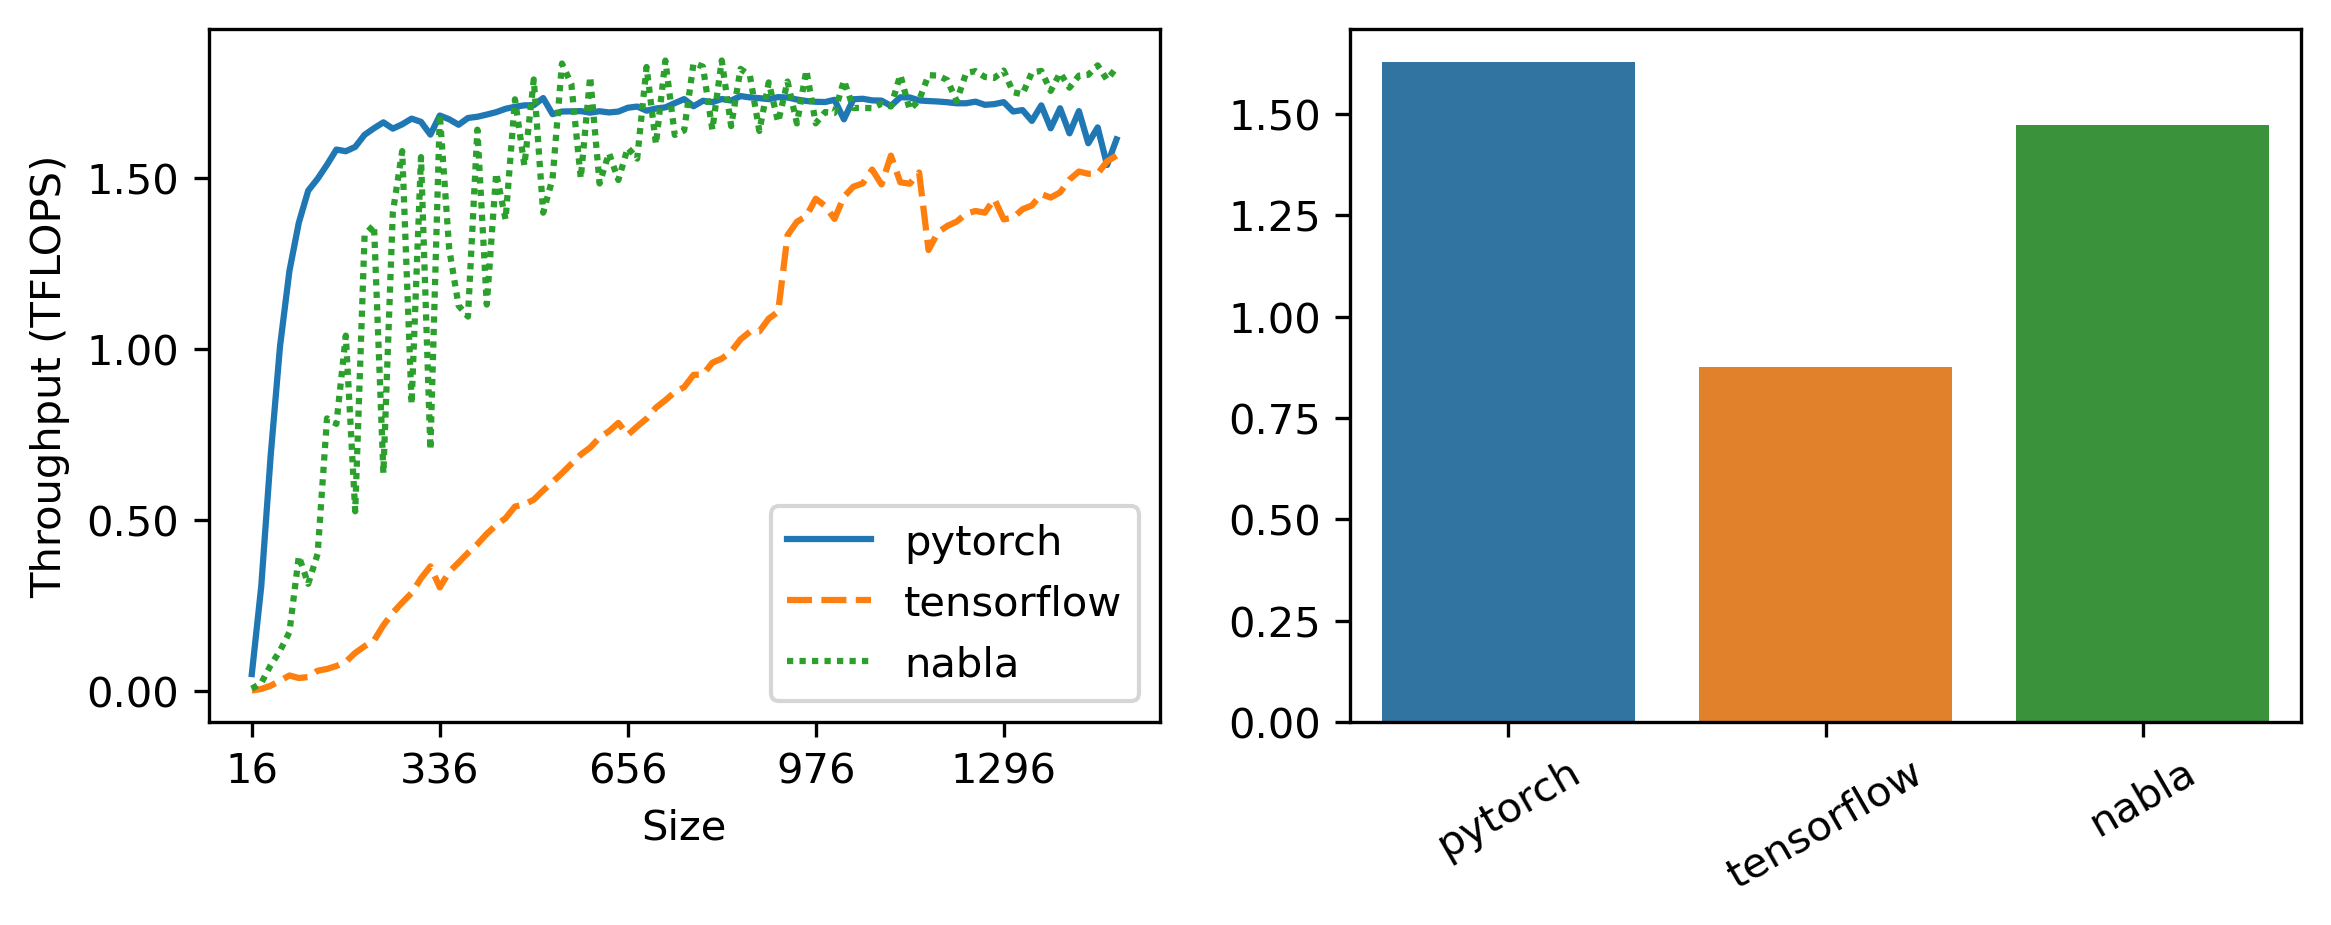

/tmp/ipykernel_876162/1917048578.py:36: UserWarning: FixedFormatter should only be used together with FixedLocator
  left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0)


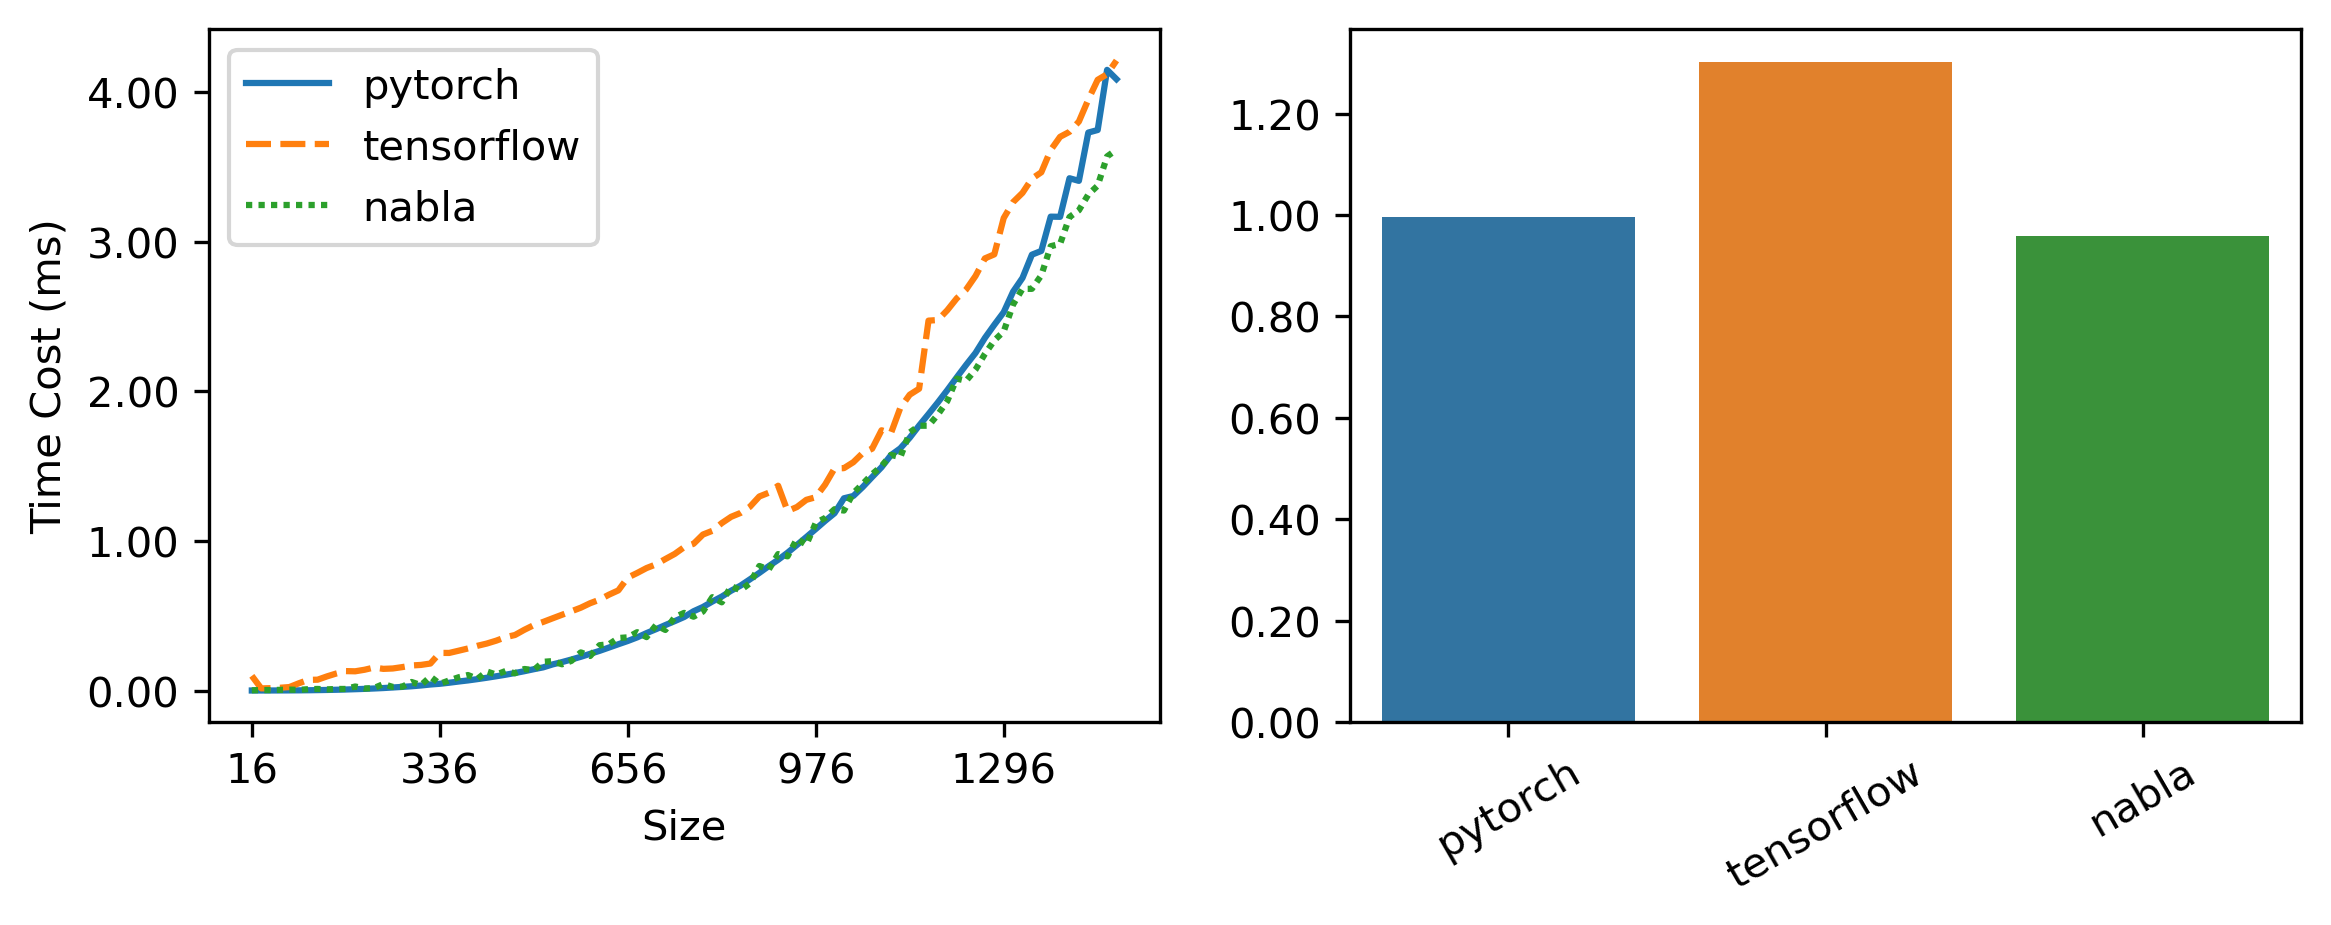

In [22]:
# do throughput
names = ['pytorch', 'tensorflow', 'nabla']
results = [torch_results, tf_results, ragdoll_results]
throughputs = [torch_throughput, tf_throughput, ragdoll_throughput]

from matplotlib.ticker import FuncFormatter
line_data = pd.DataFrame(dict(zip(names, [res for res in throughputs])))
bar_data = pd.DataFrame(dict(zip(names, [[np.mean(res)] for res in throughputs])))

plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (3, 3)

fig, (left, right) = plt.subplots(ncols=2, figsize=(9, 3))
left.set_ylabel('Throughput (TFLOPS)')
left.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1e18)))
#right.set_ylabel('Throughput (TFLOPS)')
right.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1e18)))
sns.lineplot(line_data, ax=left)
sns.barplot(bar_data, ax=right)
left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0) 
left.set_xlabel('Size')
right.set_xticklabels(right.get_xticklabels(), rotation=30) 
#plt.suptitle("Time Cost (ms)")
#plt.tight_layout(rect=[0, 0, 1, 1.2])
plt.show()

line_data = pd.DataFrame(dict(zip(names, [res for res in results])))
bar_data = pd.DataFrame(dict(zip(names, [[np.mean(res)] for res in results])))
fig, (left, right) = plt.subplots(ncols=2, figsize=(9, 3))
left.set_ylabel('Time Cost (ms)')
left.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1)))
#right.set_ylabel('Throughput (TFLOPS)')
right.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1)))
sns.lineplot(line_data, ax=left)
sns.barplot(bar_data, ax=right)
left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0) 
left.set_xlabel('Size')
right.set_xticklabels(right.get_xticklabels(), rotation=30) 
#plt.suptitle("Time Cost (ms)")
#plt.tight_layout(rect=[0, 0, 1, 1.2])
plt.show()